In [2]:
#Import libraries
import pandas as pd
pd.set_option('display.max_columns', None)
from matplotlib import pyplot as plt

from datetime import timedelta

from statsmodels.stats.proportion import proportions_ztest


 # Setting tasks

 New analyst for an international online store. Your predecessor in this position launched an A/B test and quit. All that remains is the technical specification and test results. Technical task:

 - Test name: `recommender_system_test`;

 - Groups: A (control room), B (new payment funnel);

 - Launch date: 2020-12-07

 - Stop date for recruiting new users: 2020-12-21;

 - Stop date: 2021-01-04

 - Audience: 15% of new users from the EU region;

 - Purpose of the test: testing changes associated with the implementation of an improved recommendation system;

 - Expected effect: within 14 days from the moment of registration in the system, users will show better conversion in viewing product cards (`product_page` event), viewing the product basket (`product_card` event) and purchasing (`purchase`). At each step of the funnel `product_page → product_card → purchase` the improvement will be at least 10%;

 - Expected number of test participants: 6000.

 Download the test data, check the correctness of its execution and analyze the results.

 # Analysis of test results

 Let's set the test parameters:

In [3]:
# %%
test_start = pd.to_datetime('2020-12-07')
user_acquisition_duration = 16 - 1 # т.к. нумерация дней идет с 0
activity_duration = 14 - 1
user_acquisition_end = test_start + timedelta(user_acquisition_duration)
test_end = test_start + timedelta(user_acquisition_duration + activity_duration)

required_participants = 6000

test_name = 'recommender_system_test'


 ## 1 Loading and preparing data

 Loading data, converting dates and times:

In [5]:
# Load data
test_participants = pd.read_csv('https://code.s3.yandex.net/datasets/final_ab_participants.csv')
new_users = pd.read_csv('https://code.s3.yandex.net/datasets/final_ab_new_users.csv')
events = pd.read_csv('https://code.s3.yandex.net/datasets/final_ab_events.csv')
marketing_events = pd.read_csv('https://code.s3.yandex.net/datasets/ab_project_marketing_events.csv')

#new_users = pd.read_csv('https://code.s3.yandex.net/datasets/final_ab_new_users.csv').merge(test_participants, on = 'user_id', how = 'left')
#events = pd.read_csv('https://code.s3.yandex.net/datasets/final_ab_events.csv').merge(test_participants, on = 'user_id', how = 'left')


In [6]:
test_participants.info()
test_participants.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18268 entries, 0 to 18267
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  18268 non-null  object
 1   group    18268 non-null  object
 2   ab_test  18268 non-null  object
dtypes: object(3)
memory usage: 428.3+ KB


,user_id,group,ab_test
0,D1ABA3E2887B6A73,A,recommender_system_test
1,A7A3664BD6242119,A,recommender_system_test
2,DABC14FDDFADD29E,A,recommender_system_test


In [7]:
new_users.info()
new_users.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61733 entries, 0 to 61732
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     61733 non-null  object
 1   first_date  61733 non-null  object
 2   region      61733 non-null  object
 3   device      61733 non-null  object
dtypes: object(4)
memory usage: 1.9+ MB


,user_id,first_date,region,device
0,D72A72121175D8BE,2020-12-07,EU,PC
1,F1C668619DFE6E65,2020-12-07,N.America,Android
2,2E1BF1D4C37EA01F,2020-12-07,EU,PC


In [8]:
events.info()
events.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440317 entries, 0 to 440316
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   user_id     440317 non-null  object 
 1   event_dt    440317 non-null  object 
 2   event_name  440317 non-null  object 
 3   details     62740 non-null   float64
dtypes: float64(1), object(3)
memory usage: 13.4+ MB


,user_id,event_dt,event_name,details
0,E1BDDCE0DAFA2679,2020-12-07 20:22:03,purchase,99.99
1,7B6452F081F49504,2020-12-07 09:22:53,purchase,9.99
2,9CD9F34546DF254C,2020-12-07 12:59:29,purchase,4.99


In [9]:
marketing_events.info()
marketing_events.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   name       14 non-null     object
 1   regions    14 non-null     object
 2   start_dt   14 non-null     object
 3   finish_dt  14 non-null     object
dtypes: object(4)
memory usage: 580.0+ bytes


,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03
1,St. Valentine's Day Giveaway,"EU, CIS, APAC, N.America",2020-02-14,2020-02-16
2,St. Patric's Day Promo,"EU, N.America",2020-03-17,2020-03-19


In [ ]:
#change data types
new_users['first_date'] = pd.to_datetime(new_users['first_date'])

events['event_dt'] = pd.to_datetime(events['event_dt'])

marketing_events['start_dt'] = pd.to_datetime(marketing_events['start_dt'])
marketing_events['finish_dt'] = pd.to_datetime(marketing_events['finish_dt'])

In [10]:
# merge DFs
new_users = new_users.merge(test_participants, on = 'user_id', how = 'left')
new_users.head(3)


,user_id,first_date,region,device,group,ab_test
0,D72A72121175D8BE,2020-12-07,EU,PC,A,recommender_system_test
1,F1C668619DFE6E65,2020-12-07,N.America,Android,NaN,NaN
2,2E1BF1D4C37EA01F,2020-12-07,EU,PC,A,interface_eu_test


In [11]:
events = events.merge(test_participants, on = 'user_id', how = 'left')
events.head(3)

,user_id,event_dt,event_name,details,group,ab_test
0,E1BDDCE0DAFA2679,2020-12-07 20:22:03,purchase,99.99,NaN,NaN
1,7B6452F081F49504,2020-12-07 09:22:53,purchase,9.99,NaN,NaN
2,9CD9F34546DF254C,2020-12-07 12:59:29,purchase,4.99,NaN,NaN


 Since we ourselves did not plan the test and did not monitor its implementation, we first need to check the adequacy of its implementation. Let's check:

 - Did the test coincide in time with any marketing events?

 - Did the test audience overlap with competing tests;

 - Was the test audience formed correctly;

 - Was there an even distribution among test groups?

 ## 2 Checking the correctness of the test



 Let's check the coincidence with marketing activities:

In [7]:
# %%
marketing_events['is_eu'] = marketing_events['regions'].apply(lambda x: 'EU' in x.split(', '))
eu_marketing_events = marketing_events.query('is_eu == True')
print('Test time limits: ', test_start, test_end)
eu_marketing_events.query('(start_dt >= @test_start and start_dt <= @test_end) or \
                           (finish_dt >= @test_start and finish_dt <= @test_end)')


Test time limits:  2020-12-07 00:00:00 2021-01-04 00:00:00


,name,regions,start_dt,finish_dt,is_eu
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03,True


 The test strongly overlaps with the New Year's promotion in the EU. This is not very good - you need to avoid such situations.

 Let's see how things are going with competing tests:

 Let's see how we are doing with the test participants:

In [8]:
# %%
test_participants.groupby(['ab_test', 'group']).agg({'user_id': 'nunique'})


user_id
ab_test                 group         
interface_eu_test       A         5831
                        B         5736
recommender_system_test A         3824
                        B         2877

 In addition to our test, it turns out there was also a parallel test interface_eu_test. Judging by the name, it was carried out in the EU region and could affect the result of our test. Let's see if there was an audience overlap and, if so, how big:

In [9]:
# %%
new_test_users = test_participants.query('ab_test == @test_name')['user_id'].unique()
both_test_participants = (test_participants[test_participants['user_id'].isin(new_test_users)]
                          .groupby('user_id').agg({'ab_test': 'nunique', 'group': 'nunique'})
                          .query('ab_test > 1 or group > 1').shape[0])
print('Пересечение аудитории тестов: {} ({:.2%})'.format(both_test_participants, 
                                                         both_test_participants / len(new_test_users)))



Пересечение аудитории тестов: 1602 (23.91%)


 Quite a lot, competing tests were clearly launched incorrectly.

 Let's remove from the data everything related to the competing test:

In [10]:
# %%
test_participants = test_participants.query('ab_test == @test_name')
new_users = new_users.query('ab_test != "interface_eu_test"')
events = events.query('ab_test != "interface_eu_test"')


 Let's check the correctness of the test audience.

 Let's see if the test included mainly users from the EU:

In [11]:
# %%
report = new_users.query('ab_test == @test_name').groupby('region').agg({'user_id': 'nunique'}).rename(columns = {'user_id': 'Участники'})
report['% участников'] = (report['Участники'] / report['Участники'].sum()).round(2)
report.sort_values(by = 'Участники', ascending = False)


,Участники,% участников
region,,
EU,6351,0.95
N.America,223,0.03
APAC,72,0.01
CIS,55,0.01


 There is a slight deviation - 5% of the test are users from other regions. This is acceptable.

 Now let’s check whether the test included the required proportion of users from the EU:

In [12]:
# %%
eu_test_users = new_users.query('region == "EU" and ab_test == @test_name').shape[0]
eu_users = new_users.query('region == "EU" and first_date >= @test_start and first_date <= @user_acquisition_end').shape[0]
eu_test_users / eu_users


0.181033008380366

 It turns out that instead of 15%, 18% of users from the EU are included in the test. Let's check how statistically significant this difference is.

 To do this, we will need to set and adjust the significance level. In this project we are going to run 5 statistical tests:

 - Checking % of EU audience in the test;

 - Checking the correct distribution of participants into test groups;

 - Three tests for each step of the monetization funnel.

 We carry out the Bonferroni correction and perform a z-test:

In [13]:
# %%
alpha = 0.05
alpha = alpha / 5
pvalue = proportions_ztest(eu_test_users, eu_users, value = 0.15)[1]
print('p-value: {}'.format(pvalue))
if pvalue >= alpha: 
    print('Нулевая гипотеза не отвергается: для пользователя из региона EU вероятность попасть в тест составляет 15%.')
else:
    print('Нулевая гипотеза отвергается: для пользователя из региона EU вероятность попасть в тест отличается от 15%.')


p-value: 1.7277902563754723e-51
Нулевая гипотеза отвергается: для пользователя из региона EU вероятность попасть в тест отличается от 15%.


 3% more users were sent to the test than planned. Unpleasant, but not very scary. It is unlikely that 3% could significantly affect the monetization of the entire EU audience.

 Let's check whether users are evenly distributed in groups:

In [14]:
# %%
a_users = new_users.query('group == "A" and ab_test == @test_name').shape[0]
all_participants = new_users.query('ab_test == @test_name').shape[0]
a_users / all_participants


0.5706610953589016

 Должны были поделить участников теста пополам, но, похоже, в группу А попало 57% участников вместо 50.



 Посмотрим насколько этот результат статистически значим:

In [15]:
# %%
pvalue = proportions_ztest(a_users, all_participants, value = 0.5)[1]
print('p-value: {}'.format(pvalue))
if pvalue >= alpha: 
    print('Нулевая гипотеза не отвергается: вероятность попасть в группу А составляет 50%')
else:
    print('Нулевая гипотеза отвергается: вероятность попасть в группу А отличается от 50%')


p-value: 1.50536508194716e-31
Нулевая гипотеза отвергается: вероятность попасть в группу А отличается от 50%


 Да, кажется с этим тестом все плохо. Тест явно проведен не в соответствии с ТЗ. Пересечение с параллельным тестом тоже очень неприятная штука.



 Вывод: тест проведен некорректно.



 Тем не менее, посмотрим что там за результаты получились - может быть заметим что-то полезное для следующих тестов. Сначала проведем анализ накопительных метрик.

 ## 3 Анализ накопительных метрик

 Оставим в данных только записи, касающиеся теста:

In [16]:
# %%
test_participants = test_participants.query('ab_test == @test_name')
new_users = new_users.query('ab_test == @test_name')
events = events.query('ab_test == @test_name')


 Поскольку тест уже проведен, установим текущую длительность привлечения равной полной длительности привлечения:

/var/folders/fm/f0cwhq8j4kq9xqtssrxv062m0000gn/T/ipykernel_25981/1844506081.py:70: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cumulative_test_payers.div(cumulative_test_users)[['A', 'B']].fillna(0).plot(ax = plt.subplot(2, 3, 3), grid = True)
/var/folders/fm/f0cwhq8j4kq9xqtssrxv062m0000gn/T/ipykernel_25981/1844506081.py:77: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cumulative_test_carters.div(cumulative_test_users)[['A', 'B']].fillna(0).plot(ax = plt.subplot(2, 3, 4), grid = True)
/var/folders/fm/f0cwhq8j4kq9xqtssrxv062m0000gn/T/ipykernel_25981/18

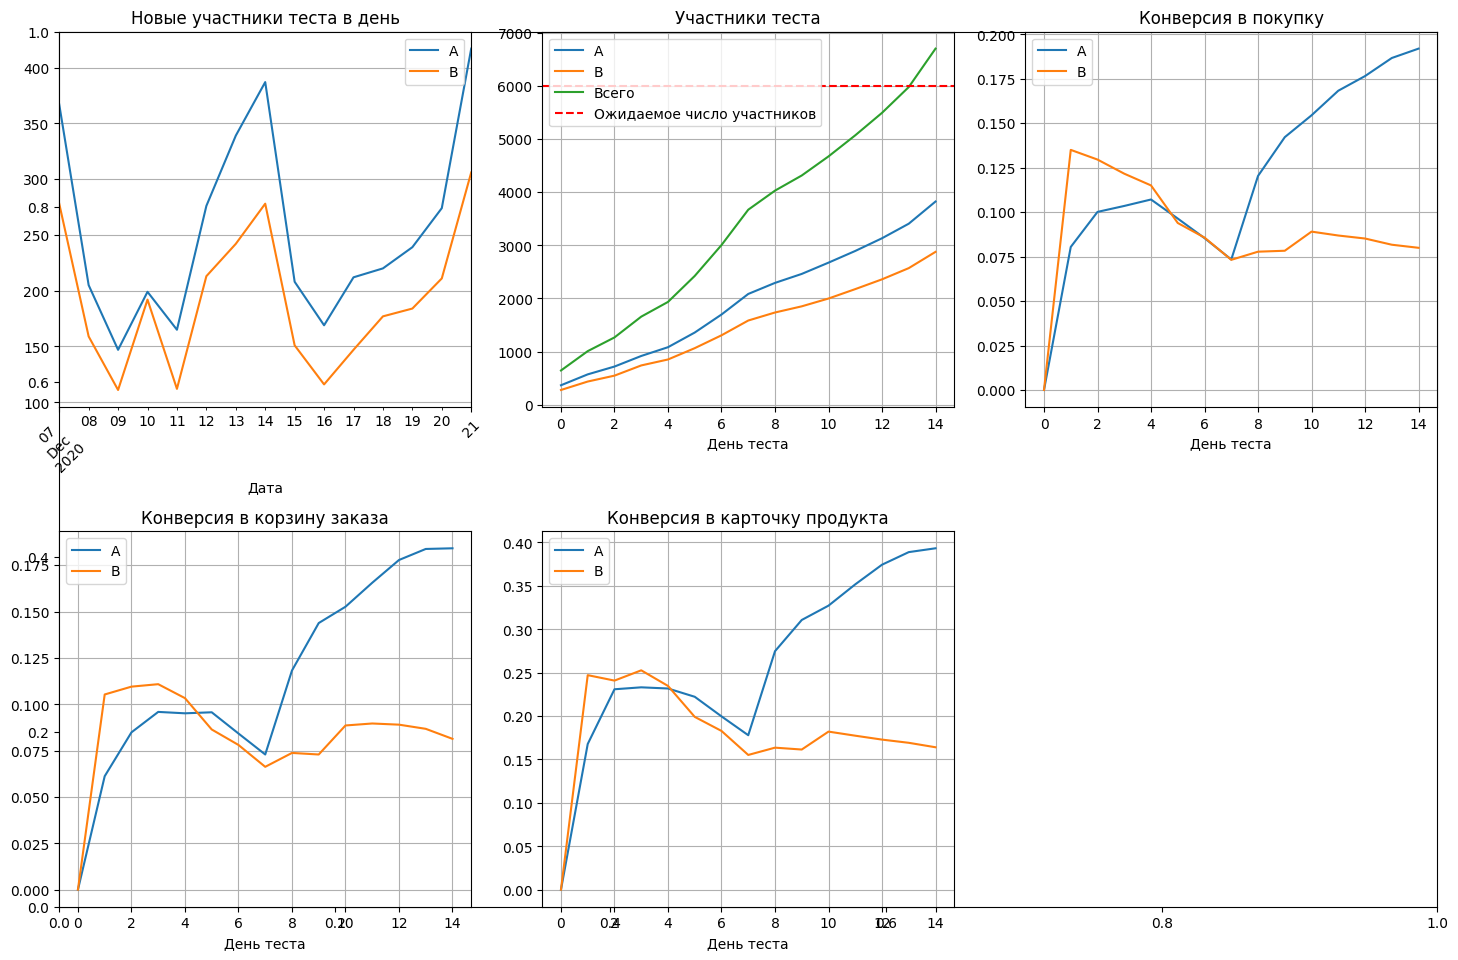

In [17]:
# %%
current_aquisition_duration = user_acquisition_duration
test_dates = pd.date_range(start = test_start, periods = current_aquisition_duration)

plt.subplots(figsize = (15, 10))

cumulative_test_users = pd.DataFrame(columns = ['A', 'B'])
cumulative_test_carters = pd.DataFrame(columns = ['A', 'B'])
cumulative_test_product = pd.DataFrame(columns = ['A', 'B'])
cumulative_test_payers = pd.DataFrame(columns = ['A', 'B'])


for i, dt in enumerate(test_dates):

    #участники теста
    current_test_users = new_users.query('first_date <= @dt').groupby('group').agg({'user_id': 'nunique'}).T
    current_test_users['date'] = dt
    current_test_users['test_day'] = i
    cumulative_test_users = pd.concat([cumulative_test_users, current_test_users], sort = False)
    
    ##карточка продукта
    current_test_prod = events.query('event_name == "product_page"').query('event_dt <= @dt').groupby('user_id').agg({'details': 'count'})
    current_test_product = (new_users.merge(current_test_prod, on = 'user_id', how = 'inner')
                                     .query('first_date <= @dt')
                                     .groupby('group').agg({'user_id': 'nunique'}).T)
    current_test_product['date'] = dt
    current_test_product['test_day'] = i
    cumulative_test_product = pd.concat([cumulative_test_product, current_test_product], sort = False)
    
    ##корзина заказа
    current_test_cart = events.query('event_name == "product_cart"').query('event_dt <= @dt').groupby('user_id').agg({'details': 'count'})
    current_test_carters = (new_users.merge(current_test_cart, on = 'user_id', how = 'inner')
                                     .query('first_date <= @dt')
                                     .groupby('group').agg({'user_id': 'nunique'}).T)
    current_test_carters['date'] = dt
    current_test_carters['test_day'] = i
    cumulative_test_carters = pd.concat([cumulative_test_carters, current_test_carters], sort = False)

    ##платящие участники теста
    current_test_purchases = events.query('event_name == "purchase"').query('event_dt <= @dt').groupby('user_id').agg({'details': 'sum'})
    current_test_payers = (new_users.merge(current_test_purchases, on = 'user_id', how = 'inner')
                                    .query('first_date <= @dt')
                                    .groupby('group').agg({'user_id': 'nunique'}).T)
    current_test_payers['date'] = dt
    current_test_payers['test_day'] = i
    cumulative_test_payers = pd.concat([cumulative_test_payers, current_test_payers], sort = False)

#новые участники теста без накопления
pd.pivot_table(new_users, 
               index = 'first_date', 
               columns = 'group', 
               values = 'user_id', 
               aggfunc = 'count').plot(ax = plt.subplot(2, 3, 1), grid = True)
plt.title('Новые участники теста в день')
plt.xlabel('Дата')
plt.xticks(rotation = 45)
plt.legend()

#участники теста
cumulative_test_users = cumulative_test_users.query('date >= @test_start and date <= @user_acquisition_end').set_index('test_day')[['A', 'B']]
cumulative_test_users['Всего'] = cumulative_test_users['A'] + cumulative_test_users['B']
cumulative_test_users.plot(ax = plt.subplot(2, 3, 2), grid = True)
plt.axhline(y = required_participants, label = 'Ожидаемое число участников', color = 'red', linestyle = '--')
plt.title('Участники теста')
plt.legend()
plt.xlabel('День теста')

#конверсии 
cumulative_test_payers = cumulative_test_payers.query('date >= @test_start and date <= @user_acquisition_end').set_index('test_day')[['A', 'B']]
cumulative_test_payers.div(cumulative_test_users)[['A', 'B']].fillna(0).plot(ax = plt.subplot(2, 3, 3), grid = True)
plt.title('Конверсия в покупку')
plt.legend()
plt.xlabel('День теста')

#конверсии в корзину
cumulative_test_carters = cumulative_test_carters.query('date >= @test_start and date <= @user_acquisition_end').set_index('test_day')[['A', 'B']]
cumulative_test_carters.div(cumulative_test_users)[['A', 'B']].fillna(0).plot(ax = plt.subplot(2, 3, 4), grid = True)
plt.title('Конверсия в корзину заказа')
plt.legend()
plt.xlabel('День теста')

#конверсии в корзину
cumulative_test_product = cumulative_test_product.query('date >= @test_start and date <= @user_acquisition_end').set_index('test_day')[['A', 'B']]
cumulative_test_product.div(cumulative_test_users)[['A', 'B']].fillna(0).plot(ax = plt.subplot(2, 3, 5), grid = True)
plt.title('Конверсия в карточку продукта')
plt.legend()
plt.xlabel('День теста')

plt.tight_layout()
plt.show()


 Выводы и наблюдения:

 - Данные показывают недельную сезонность, наобходимый уровень участников был достигнут. В этой части тест был спланирован верно;

 - Конверсии в каждый из шагов воронки ощутимо разошлись, похоже, что лидировала группа А.



 Проверим это с помощью статистических тестов.

 ## 4 Проверка гипотез

 Проверим, есть ли отличие между группами в конверсии в покупку. Используем z-тест, поскольку тестируется пропорция:

In [18]:
# %%
report = test_participants.merge(events.query('event_name == "purchase"').groupby('user_id').agg({'details': 'count'}), on = 'user_id', how = 'left')
report['is_buyer'] = (report['details'] > 0).astype(int)
report = (report.groupby('group').agg({'user_id': 'count', 'is_buyer': 'sum'})
                                 .rename(columns = {'user_id': 'Участники', 'is_buyer': 'Покупатели'}))
report['Конверсия'] = (report['Покупатели'] / report['Участники']).round(2)
report


,Участники,Покупатели,Конверсия
group,,,
A,3824,872,0.23
B,2877,256,0.09


In [19]:
# %%
count = list(report['Покупатели'].values)
nobs = list(report['Участники'].values)

pvalue = proportions_ztest(count, nobs)[1]
print('p-value: {}'.format(pvalue))
if pvalue >= alpha: 
    print('Нулевая гипотеза не отвергается: между группами A и B нет различий в % конверсии в покупку.')
else:
    print('Нулевая гипотеза отвергается: между группами A и B есть различие % конверсии в покупку.')


p-value: 3.044251010416302e-51
Нулевая гипотеза отвергается: между группами A и B есть различие % конверсии в покупку.


 Проверим, есть ли отличие между группами в % пользователей, посетивших страницу продукта. Используем z-тест, поскольку тестируется пропорция:

In [20]:
# %%
report = test_participants.merge(events.query('event_name == "product_page"').groupby('user_id').agg({'event_dt': 'count'}), on = 'user_id', how = 'left')
report['is_buyer'] = (report['event_dt'] > 0).astype(int)
report = (report.groupby('group').agg({'user_id': 'count', 'is_buyer': 'sum'})
                                 .rename(columns = {'user_id': 'Участники', 'is_buyer': 'Пользователи на странице продукта'}))
report['Конверсия'] = (report['Пользователи на странице продукта'] / report['Участники']).round(2)
report


,Участники,Пользователи на странице продукта,Конверсия
group,,,
A,3824,1780,0.47
B,2877,523,0.18


In [21]:
# %%
count = list(report['Пользователи на странице продукта'].values)
nobs = list(report['Участники'].values)

pvalue = proportions_ztest(count, nobs)[1]
print('p-value: {}'.format(pvalue))
if pvalue >= alpha: 
    print('Нулевая гипотеза не отвергается: между группами A и B нет различий в % пользователей, видевших страницу продукта.')
else:
    print('Нулевая гипотеза отвергается: между группами A и B есть различие % пользователей, видевших страницу продукта.')


p-value: 2.0521014454928e-129
Нулевая гипотеза отвергается: между группами A и B есть различие % пользователей, видевших страницу продукта.


 Проверим, есть ли отличие между группами в % пользователей, посетивших страницу корзины. Используем z-тест, поскольку тестируется пропорция:

In [22]:
# %%
report = test_participants.merge(events.query('event_name == "product_cart"').groupby('user_id').agg({'event_dt': 'count'}), on = 'user_id', how = 'left')
report['is_buyer'] = (report['event_dt'] > 0).astype(int)
report = (report.groupby('group').agg({'user_id': 'count', 'is_buyer': 'sum'})
                                 .rename(columns = {'user_id': 'Участники', 'is_buyer': 'Пользователи на странице корзины'}))
report['Конверсия'] = (report['Пользователи на странице корзины'] / report['Участники']).round(2)
report


,Участники,Пользователи на странице корзины,Конверсия
group,,,
A,3824,824,0.22
B,2877,255,0.09


In [23]:
# %%
count = list(report['Пользователи на странице корзины'].values)
nobs = list(report['Участники'].values)

pvalue = proportions_ztest(count, nobs)[1]
print('p-value: {}'.format(pvalue))
if pvalue >= alpha: 
    print('Нулевая гипотеза не отвергается: между группами A и B нет различий в % пользователей, видевших страницу корзины.')
else:
    print('Нулевая гипотеза отвергается: между группами A и B есть различие % пользователей, видевших страницу корзины.')


p-value: 1.95915226847382e-44
Нулевая гипотеза отвергается: между группами A и B есть различие % пользователей, видевших страницу корзины.


 Разница в пользу контрольной группы А, которую мы видели при анализе накопительных метрик, подтвержается статистическими тестами. Похоже, что улучшенная рекомендательная система ничего не улучшила, а даже наоборот. Конечно, тест у нас проведен некорректно, но к этим улучшениями нужно относиться с подозрением. Рекомендуем провести еще один тест - на этот раз соответствующий ТЗ.

 # Выводы

 Выводы:

 1. Тест был проведен некорректно:

     - Тест совпал по времени с новогодними промо в регионе EU;

     - Участники теста параллельно участвовали в еще одном тесте;

     - В тест было набрано на 3% больше участников из региона EU, чем нужно;

     - Участники теста были неравномерно распределены между тестовыми группами в группу А попало 57% участников.

 Таким образом, результаты теста нельзя считать валидными и основывать на них какие-либо бизнес решения.



 2. Тем не менее, результаты теста показывают, что к новой рекомендательной системе нужно относиться с подозрением - конверсия в тестовой группе была намного ниже, чем в контрольной.



 3. Рекомендуется провести еще один тест, чтобы получить корректные результаты.